# Step 3 — Feature Engineering

## Objective

Transform the cleaned data into features that are easier for machine-learning models to use.

The engineered features are intentionally simple and interpretable:

- restaurant-to-customer distance (`Distance_km`);
- order hour (`Order_Hour`);
- pickup hour (`Pickup_Hour`);
- preparation time (`Preparation_Time_min`);
- day, month, day of week, and weekend indicator.

`Pickup_Hour` and `Preparation_Time_min` are derived from `Time_Order_picked`, which is only available once the order has been picked up. Using these features therefore changes the prediction point: the model is framed around prediction at pickup rather than at the original order time.


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(style="whitegrid")

TARGET = "Time_taken(min)"

PROJECT_ROOT = Path(f"{Path.cwd()}/03_feature_engineering.ipynb").resolve().parents[1]
INPUT_PATH = PROJECT_ROOT / "data" /  "food-delivery-cleaned.csv"
OUTPUT_PATH = PROJECT_ROOT / "data"  / "food-delivery-features.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "feature_engineering"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path


## 1. Load the cleaned dataset

This notebook starts from the output of the cleaning step.

At this point:

- identifier columns have already been removed;
- `Vehicle_condition` is kept as a nominal categorical variable;
- `Time_Orderd` and `Time_Order_picked` are complete;
- `Time_Order_picked` is kept temporarily to create `Pickup_Hour` and `Preparation_Time_min`.


In [8]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at {INPUT_PATH}. Run 01_cleaning.ipynb first."
    )

df = pd.read_csv(INPUT_PATH)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")

df["Vehicle_condition"] = df["Vehicle_condition"].astype("category")

print(f"Shape: {df.shape}")
display(df.head())


Shape: (41953, 18)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.000,4.900,22.745,75.892,22.765,75.912,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0.000,No,Urban,24
1,34.000,4.500,12.913,77.683,13.043,77.813,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1.000,No,Metropolitian,33
2,23.000,4.400,12.914,77.678,12.924,77.688,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.000,No,Urban,26
3,38.000,4.700,11.004,76.976,11.054,77.026,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.000,No,Metropolitian,21
4,32.000,4.600,12.973,80.250,13.013,80.290,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1.000,No,Metropolitian,30


## 2. Checks before transformation

The GPS columns are required to calculate distance, and the temporal columns must be available for the time-based features.

Since `Time_Orderd` and `Time_Order_picked` were completed during cleaning, no missing-time indicator is needed here.


In [9]:
required_columns = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Vehicle_condition",
    TARGET,
]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

print("Missing values before feature engineering:")
display(df[required_columns].isna().sum().to_frame("missing"))


Missing values before feature engineering:


,missing
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Vehicle_condition,0
Time_taken(min),0


## 3. Temporal features

The raw date and time columns contain useful information, but datetime objects are not used directly by most regression models.

We create:

- `Order_Hour`: hour when the order was placed;
- `Order_Day`: day of the month;
- `Order_Month`: month;
- `Order_DayOfWeek`: day of the week from 0 to 6;
- `Is_Weekend`: 1 for Saturday or Sunday, otherwise 0;
- `Pickup_Hour`: hour when the order was picked up;
- `Preparation_Time_min`: time between the order and pickup, including midnight rollover.

Because `Pickup_Hour` and `Preparation_Time_min` depend on `Time_Order_picked`, they assume prediction is made at pickup time.


In [10]:
def create_temporal_features(data):
    data = data.copy()

    data["Order_Hour"] = data["Time_Orderd"].dt.hour
    data["Order_Day"] = data["Order_Date"].dt.day
    data["Order_Month"] = data["Order_Date"].dt.month
    data["Order_DayOfWeek"] = data["Order_Date"].dt.dayofweek
    data["Is_Weekend"] = (
        data["Order_DayOfWeek"]
        .isin([5, 6])
        .astype("int8")
    )

    data["Pickup_Hour"] = data["Time_Order_picked"].dt.hour

    prep_diff = (
        data["Time_Order_picked"] - data["Time_Orderd"]
    ).dt.total_seconds() / 60
    prep_diff = np.where(prep_diff < 0, prep_diff + 24 * 60, prep_diff)
    data["Preparation_Time_min"] = prep_diff

    return data

df = create_temporal_features(df)

temporal_columns = [
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Order_DayOfWeek",
    "Is_Weekend",
    "Pickup_Hour",
    "Preparation_Time_min",
]

display(df[temporal_columns].head(10))
display(df[temporal_columns].isna().sum().to_frame("missing"))

,Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min
0,11,19,3,5,1,11,15.000
1,19,25,3,4,0,19,5.000
2,8,19,3,5,1,8,15.000
3,18,5,4,1,0,18,10.000
4,13,26,3,5,1,13,15.000
5,21,11,3,4,0,21,10.000
6,19,4,3,4,0,19,15.000
7,17,14,3,0,0,17,5.000
8,20,20,3,6,1,21,10.000
9,21,12,2,5,1,22,15.000


,missing
Order_Hour,0
Order_Day,0
Order_Month,0
Order_DayOfWeek,0
Is_Weekend,0
Pickup_Hour,0
Preparation_Time_min,0


## 4. Geographic feature: `Distance_km`

The four GPS coordinates indirectly describe the distance between the restaurant and the customer.

We convert them into a single straight-line distance using the **Haversine formula**:

\[
a = \sin^2(\Delta\varphi/2)
+ \cos(\varphi_1)\cos(\varphi_2)\sin^2(\Delta\lambda/2)
\]

\[
c = 2\arctan2(\sqrt{a},\sqrt{1-a})
\]

\[
d = R \times c
\]

with `R = 6371 km`.

This is not the actual road distance, but it provides a consistent geographic measure.


In [11]:
def haversine_distance_km(
    latitude_1,
    longitude_1,
    latitude_2,
    longitude_2,
):
    earth_radius_km = 6371.0

    lat1 = np.radians(latitude_1)
    lon1 = np.radians(longitude_1)
    lat2 = np.radians(latitude_2)
    lon2 = np.radians(longitude_2)

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    a = np.clip(a, 0, 1)

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a),
    )

    return earth_radius_km * c

df["Distance_km"] = haversine_distance_km(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"],
)

print("Distance_km statistics:")
display(df["Distance_km"].describe())


Distance_km statistics:


count   41953.000
mean        9.720
std         5.603
min         1.465
25%         4.658
50%         9.193
75%        13.681
max        20.969
Name: Distance_km, dtype: float64

## 5. Check `Distance_km`

Very large GPS distances can indicate unusual observations or coordinate problems.

Extreme values are inspected rather than removed automatically. As in the cleaning step, a statistical outlier is not automatically treated as a data error.


In [12]:
distance_summary = df["Distance_km"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(distance_summary)

print("Distance < 1 km:", (df["Distance_km"] < 1).sum())
print("Distance > 50 km:", (df["Distance_km"] > 50).sum())
print("Distance > 100 km:", (df["Distance_km"] > 100).sum())
print("Missing Distance_km:", df["Distance_km"].isna().sum())


count   41953.000
mean        9.720
std         5.603
min         1.465
1%          1.490
5%          1.532
25%         4.658
50%         9.193
75%        13.681
95%        19.917
99%        20.831
max        20.969
Name: Distance_km, dtype: float64

Distance < 1 km: 0
Distance > 50 km: 0
Distance > 100 km: 0
Missing Distance_km: 0


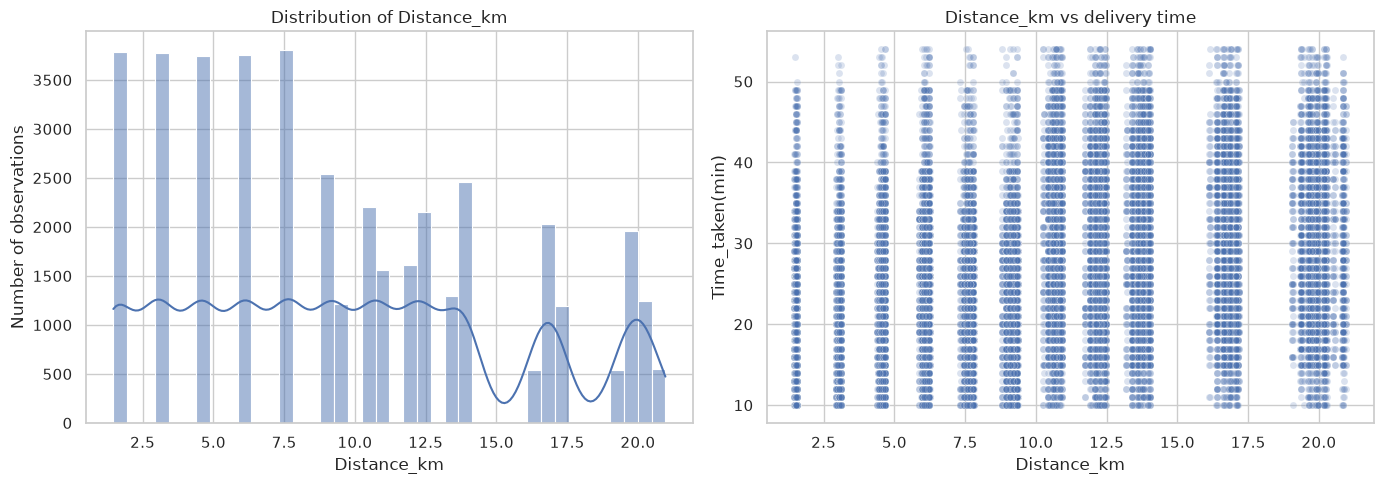

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Distance_km"],
    kde=True,
    bins=40,
    ax=axes[0],
)
axes[0].set_title("Distribution of Distance_km")
axes[0].set_xlabel("Distance_km")
axes[0].set_ylabel("Number of observations")

sns.scatterplot(
    data=df,
    x="Distance_km",
    y=TARGET,
    alpha=0.20,
    s=25,
    ax=axes[1],
)
axes[1].set_title("Distance_km vs delivery time")
axes[1].set_xlabel("Distance_km")
axes[1].set_ylabel(TARGET)

plt.tight_layout()
save_fig("distance_distribution_and_target_relationship.png")
plt.show()


## 6. Relationship with the target

After creating the new features, we check how they relate to the target.

- `Distance_km`, `Order_Hour`, `Order_Day`, `Order_Month`, `Pickup_Hour`, and `Preparation_Time_min` are first examined with Spearman correlation.
- `Order_DayOfWeek` and `Is_Weekend` are compared by group and with eta-squared because they are categorical or binary.

These are descriptive relationships, not evidence of causality.

### 6.1 Numeric and ordinal features


In [14]:
engineered_numeric = [
    "Distance_km",
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Pickup_Hour",
    "Preparation_Time_min",
]

engineered_numeric_relationships = (
    df[engineered_numeric + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .to_frame("spearman")
)

engineered_numeric_relationships["abs_spearman"] = (
    engineered_numeric_relationships["spearman"].abs()
)

engineered_numeric_relationships = (
    engineered_numeric_relationships
    .sort_values("abs_spearman", ascending=False)
)

display(engineered_numeric_relationships)

,spearman,abs_spearman
Distance_km,0.319,0.319
Pickup_Hour,0.132,0.132
Order_Hour,0.102,0.102
Order_Day,0.025,0.025
Order_Month,-0.012,0.012
Preparation_Time_min,-0.008,0.008


### 6.2 Categorical and binary features

`Order_DayOfWeek` and `Is_Weekend` are evaluated by comparing delivery times across groups.


In [15]:
def eta_squared(data, category_column, target_column):
    valid = data[[category_column, target_column]].dropna()

    grand_mean = valid[target_column].mean()

    group_stats = (
        valid.groupby(category_column)[target_column]
        .agg(["count", "mean"])
    )

    between_ss = (
        group_stats["count"]
        * (group_stats["mean"] - grand_mean) ** 2
    ).sum()

    total_ss = (
        (valid[target_column] - grand_mean) ** 2
    ).sum()

    if total_ss == 0:
        return 0.0

    return between_ss / total_ss

In [16]:
engineered_categorical = [
    "Order_DayOfWeek",
    "Is_Weekend",
]

engineered_categorical_relationships = []

for column in engineered_categorical:
    engineered_categorical_relationships.append({
        "feature": column,
        "eta_squared": eta_squared(df, column, TARGET),
        "n_unique": df[column].nunique(dropna=False),
    })

engineered_categorical_relationships = (
    pd.DataFrame(engineered_categorical_relationships)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

display(engineered_categorical_relationships)

,feature,eta_squared,n_unique
0,Order_DayOfWeek,0.007,7
1,Is_Weekend,0.000,2


### 6.3 Group summaries


In [17]:
hour_summary = (
    df.groupby("Order_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

pickup_hour_summary = (
    df.groupby("Pickup_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

weekday_summary = (
    df.groupby("Order_DayOfWeek", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

weekend_summary = (
    df.groupby("Is_Weekend", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print("Delivery time by order hour:")
display(hour_summary)

print("Delivery time by pickup hour:")
display(pickup_hour_summary)

print("Delivery time by day of week:")
display(weekday_summary)

print("Delivery time by weekend indicator:")
display(weekend_summary)


Delivery time by order hour:


,Order_Hour,count,mean,median,std
0,0,415,22.229,21.000,7.251
1,8,1749,19.623,19.000,5.613
2,9,1878,19.481,19.000,5.524
3,10,1887,19.484,19.000,5.532
4,11,1865,26.478,27.000,8.317
5,12,860,26.877,27.000,8.736
6,13,748,27.766,27.000,8.686
7,14,756,27.308,27.000,8.238
8,15,831,23.237,23.000,6.949
9,16,676,23.055,24.000,6.895


Delivery time by pickup hour:


,Pickup_Hour,count,mean,median,std
0,0,1212,22.307,21.000,7.449
1,8,1378,19.587,19.000,5.637
2,9,1885,19.538,19.000,5.518
3,10,1937,19.494,19.000,5.534
4,11,1827,25.076,25.000,8.209
5,12,1075,27.029,27.000,8.772
6,13,735,27.623,27.000,8.676
7,14,749,27.637,27.000,8.530
8,15,830,23.811,25.000,7.164
9,16,711,23.152,25.000,6.864


Delivery time by day of week:


,Order_DayOfWeek,count,mean,median,std
0,0,5722,26.227,25.000,9.326
1,1,5884,25.435,25.000,9.089
2,2,6552,27.762,27.000,9.730
3,3,5841,25.284,25.000,9.013
4,4,6408,26.823,26.000,9.516
5,5,5810,25.973,25.000,9.284
6,6,5736,26.457,25.500,9.390


Delivery time by weekend indicator:


,Is_Weekend,count,mean,median,std
0,0,30407,26.349,26.000,9.396
1,1,11546,26.214,25.000,9.340


`Distance_km` has a Spearman association of **0.319** with the target, while `Order_Hour` has a weaker association of **0.102**.

The other temporal features are weak individually, but they may still be useful in combination with other variables.


## 7. Remove raw GPS and datetime columns

Once the engineered features have been created, the raw columns are no longer needed:

- the four GPS coordinates are replaced by `Distance_km`;
- `Order_Date` and `Time_Orderd` are represented by the calendar and order-time features;
- `Time_Order_picked` is represented by `Pickup_Hour` and `Preparation_Time_min`.

The raw GPS coordinates are dropped rather than kept alongside `Distance_km` because the latitude and longitude pairs are highly redundant and their individual relationships with the target are weak.


In [18]:
GPS_COLUMNS = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

RAW_DATETIME_COLUMNS = [
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
]

df = df.drop(
    columns=GPS_COLUMNS + RAW_DATETIME_COLUMNS,
    errors="ignore",
)

print("Columns after removing raw GPS and datetime fields:")
print(df.columns.tolist())


Columns after removing raw GPS and datetime fields:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'Order_Hour', 'Order_Day', 'Order_Month', 'Order_DayOfWeek', 'Is_Weekend', 'Pickup_Hour', 'Preparation_Time_min', 'Distance_km']


## 8. Final feature check

The engineered dataset should:

- keep the target;
- contain all newly created features;
- contain no raw GPS or datetime columns;
- contain no missing values;
- be ready for the later `X` / `y` split.

Model-specific preprocessing such as encoding and scaling will be handled in the scikit-learn pipeline after the train/test split.


In [19]:
new_features = [
    "Distance_km",
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Order_DayOfWeek",
    "Is_Weekend",
    "Pickup_Hour",
    "Preparation_Time_min",
]

missing_new_features = [
    column for column in new_features
    if column not in df.columns
]

if missing_new_features:
    raise ValueError(
        f"Expected features are missing : {missing_new_features}"
    )

print("Created features:")
for feature in new_features:
    print(f"- {feature}")

print("\nFinal shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nPreview:")
display(df.head())


Created features:
- Distance_km
- Order_Hour
- Order_Day
- Order_Month
- Order_DayOfWeek
- Is_Weekend
- Pickup_Hour
- Preparation_Time_min

Final shape: (41953, 19)

Missing values:


,missing
Delivery_person_Age,0
Delivery_person_Ratings,0
Weatherconditions,0
Road_traffic_density,0
Vehicle_condition,0
Type_of_order,0
Type_of_vehicle,0
multiple_deliveries,0
Festival,0
City,0



Preview:


,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min,Distance_km
0,37.000,4.900,Sunny,High,2,Snack,motorcycle,0.000,No,Urban,24,11,19,3,5,1,11,15.000,3.025
1,34.000,4.500,Stormy,Jam,2,Snack,scooter,1.000,No,Metropolitian,33,19,25,3,4,0,19,5.000,20.184
2,23.000,4.400,Sandstorms,Low,0,Drinks,motorcycle,1.000,No,Urban,26,8,19,3,5,1,8,15.000,1.553
3,38.000,4.700,Sunny,Medium,0,Buffet,motorcycle,1.000,No,Metropolitian,21,18,5,4,1,0,18,10.000,7.790
4,32.000,4.600,Cloudy,High,1,Snack,scooter,1.000,No,Metropolitian,30,13,26,3,5,1,13,15.000,6.210


## 9. Feature groups for modeling

The final features have different statistical roles, which will be reflected in the preprocessing pipeline.

### Numeric features

```python
NUMERIC_FEATURES = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Distance_km",
    "Order_Day",
    "Preparation_Time_min",
]
```

### Categorical features

```python
CATEGORICAL_FEATURES = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Vehicle_condition",
    "Order_Hour",
    "Order_Month",
    "Order_DayOfWeek",
    "Pickup_Hour",
]
```

`Order_Hour`, `Pickup_Hour`, and `Order_Month` are treated as categorical candidates so the model is not forced to assume a simple linear relationship between their values.

### Binary features

```python
BINARY_FEATURES = [
    "Is_Weekend",
]
```

Encoding and scaling will be defined in the modeling notebook and applied inside the pipeline after the train/test split.


## 10. Audit of raw-column removal and prediction timing

`Pickup_Hour` and `Preparation_Time_min` are derived from `Time_Order_picked`, so they are only available at pickup time.

The audit below checks that the original GPS and datetime columns have been removed and that the target is not included in `X`.


In [20]:
X = df.drop(columns=[TARGET])

RAW_COLUMNS_TO_EXCLUDE = [
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

raw_present = [
    column
    for column in RAW_COLUMNS_TO_EXCLUDE
    if column in df.columns
]

if raw_present:
    raise ValueError(
        f"Raw columns are still present : {raw_present}"
    )

if TARGET in X.columns:
    raise ValueError(
        "The target must not be present in X."
    )

print("Feature audit: OK")
print("No raw GPS or datetime columns remain in the final dataset.")
print(
    "\nPickup_Hour and Preparation_Time_min are derived from Time_Order_picked, "
    "so this feature set assumes prediction at pickup time."
)


Feature audit: OK
No raw GPS or datetime columns remain in the final dataset.

Pickup_Hour and Preparation_Time_min are derived from Time_Order_picked, so this feature set assumes prediction at pickup time.


## 11. Features and target

The target remains:

`Time_taken(min)`

All other columns are candidate predictors.

The physical train/test split will be performed in the modeling step, where preprocessing and the regression model can be placed inside a single pipeline.


In [21]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX data types:")
display(X.dtypes.to_frame("dtype"))


X shape: (41953, 18)
y shape: (41953,)

X data types:


,dtype
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Weatherconditions,str
Road_traffic_density,str
Vehicle_condition,category
Type_of_order,str
Type_of_vehicle,str
multiple_deliveries,float64
Festival,str
City,str


In [22]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved engineered dataset to: {OUTPUT_PATH}")
print(f"Saved shape: {df.shape}")


Saved engineered dataset to: /home/houssam/Desktop/Briefs/Brief 2/data/food-delivery-features.csv
Saved shape: (41953, 19)


# 12. Final decisions

The feature-engineering step produces eight new features:

| Feature | Role |
|---|---|
| `Distance_km` | Numeric |
| `Order_Hour` | Categorical candidate |
| `Pickup_Hour` | Categorical candidate |
| `Preparation_Time_min` | Numeric |
| `Order_Day` | Numeric candidate |
| `Order_Month` | Categorical candidate |
| `Order_DayOfWeek` | Categorical |
| `Is_Weekend` | Binary |

The four GPS coordinates are replaced by `Distance_km`, and the raw date/time columns are removed after their useful information has been extracted.

`Pickup_Hour` and `Preparation_Time_min` are intentionally retained even though they depend on `Time_Order_picked`. Their use means the model is framed around prediction at pickup time.

The final engineered dataset is saved to:

```text
data/processed/food_delivery_features.csv
```

Encoding, scaling, train/test splitting, and model training are left for the modeling stage.
